# بنچمارک مصرف انرژی ساختمان‌های کلگری
[English](analysis.en.ipynb) · [معرفی پروژه](../README.fa.md) · [روش پژوهش](../docs/methods.fa.md)

این مطالعه بررسی می‌کند که کاربری، مساحت، سال ساخت و سال گزارش تا چه حد شدت مصرف سالانهٔ انرژی را در داده‌های عمومی کلگری توضیح می‌دهند. ارزیابی برای ملک دیده‌نشده، محدودهٔ مکانی کنارگذاشته‌شده و سال آینده جداگانه انجام می‌شود.

منبع داده [برنامهٔ BenchmarkYYC](https://www.calgary.ca/environment/programs/building-energy-benchmarking-program.html) و [نقشهٔ عمومی عملکرد ساختمان‌ها](https://grid.opentech.eco/orgs/calgary/viz) است. یک شناسهٔ ملک ممکن است بیش از یک ساختمان را پوشش دهد. نمونهٔ عمومی، سرشماری ساختمان‌های کلگری نیست.

نسخهٔ مرجع در ۲۴ سپتامبر ۲۰۲۶ دریافت شده و دادهٔ ۲۰۲۵ موقت در نظر گرفته شده است. پس از دریافت داده سلول‌ها را به‌ترتیب اجرا کنید. مسیر داده با `BENCHMARKYYC_SNAPSHOT` و نتایج با `BENCHMARKYYC_RESULTS` قابل تعیین است. کد دو نسخهٔ زبانی یکسان است.

## ۱. خواندن و کنترل نسخهٔ داده
پیش از تحلیل، هش CSV کنترل می‌شود. هش پاسخ‌های منبع، دوره‌های گزارش و واحدها در فایل منشأ ثبت شده‌اند. واحد Site EUI کیلووات‌ساعت بر مترمربع در سال است؛ نرمال‌سازی آب‌وهوایی فرض نمی‌شود. داده فقط رکوردهای منتشرشده در مسیر عمومی در زمان دریافت را پوشش می‌دهد.

In [1]:
from pathlib import Path
import os, sys, json, hashlib, importlib.metadata
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "benchmarkyyc").is_dir():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("Open this notebook inside the project directory.")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
DATA = Path(os.environ.get("BENCHMARKYYC_SNAPSHOT", str(ROOT / "data/snapshots/2026-09-24-release"))).resolve()
OUT = Path(os.environ.get("BENCHMARKYYC_RESULTS", str(ROOT / "results/local"))).resolve()
OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size":10,"figure.dpi":120,"axes.spines.top":False,"axes.spines.right":False})
SEED=42
raw=pd.read_csv(DATA / "panel.csv")
provenance=json.loads((DATA / "provenance.json").read_text(encoding="utf-8"))
assert not raw.duplicated(["property_id","report_year"]).any()
assert hashlib.sha256((DATA/"panel.csv").read_bytes()).hexdigest()==provenance["panel_sha256"]
versions={p:importlib.metadata.version(p) for p in ["pandas","numpy","matplotlib","scikit-learn","shap"]}
versions.update(python=sys.version,input_sha256=provenance["panel_sha256"])
(OUT/"execution_metadata.json").write_text(json.dumps(versions,indent=2),encoding="utf-8")
print("Snapshot retrieved:",provenance["downloaded_utc"])
print("Property-year records:",len(raw),"Unique property IDs:",raw.property_id.nunique())
display(raw.groupby("report_year").agg(records=("property_id","size"),properties=("property_id","nunique"),site_eui_available=("site_eui","count")))
display(pd.Series(versions,name="Version"))


Snapshot retrieved: 2026-09-24T10:54:40.894174+00:00
Property-year records: 2781 Unique property IDs: 654


,records,properties,site_eui_available
report_year,,,
2019,269,269,268
2020,278,278,278
2021,282,282,282
2022,346,346,346
2023,580,580,580
2024,559,559,559
2025,467,467,467


pandas                                                      3.0.1
numpy                                                       2.3.5
matplotlib                                                 3.11.2
scikit-learn                                                1.9.1
shap                                                       0.52.0
python          3.12.14 (main, Aug 25 2026, 14:01:42) [MSC v.1...
input_sha256    56bcb331177d8717bebd78e5482fd626986b13e8fc384d...
Name: Version, dtype: str

## ۲. ممیزی مشاهدات
جدول خام تغییر نمی‌کند. رکوردهای فاقد هدف مثبت از مدل کنار گذاشته و تعدادشان گزارش می‌شود. سال ساخت پس از سال گزارش فقط در نسخهٔ تحلیلی گمشده محسوب می‌شود؛ پرکردن مقدار در هر بخش آموزش انجام می‌گیرد. مصرف‌های بالا خودکار حذف نمی‌شوند.

تغییر مساحت می‌تواند ناشی از بازسازی، تغییر محدودهٔ ملک یا اصلاح اطلاعات باشد. داده‌های تاریخی فعلی ممکن است با نسخهٔ منتشرشده در همان سال تفاوت داشته باشند؛ آزمون زمانی بر نسخهٔ بازنگری‌شده انجام می‌شود.

In [2]:
quality=pd.DataFrame({'missing':raw.isna().sum(),'unique':raw.nunique()})
display(quality)
invalid_year=raw.year_built>raw.report_year
display(raw.loc[invalid_year,['property_id','report_year','year_built']])
area_ratio=raw.groupby('property_id').floor_area_m2.max()/raw.groupby('property_id').floor_area_m2.min()
print('Properties with >1% area variation:',int((area_ratio>1.01).sum()))
display(raw.city.value_counts().rename('city_labels'))
check=raw[['property_id','report_year','floor_area_m2','ghg_intensity','total_ghg_t']].copy()
check['expected_total_ghg_t']=check.floor_area_m2*check.ghg_intensity/1000
check['difference_t']=check.total_ghg_t-check.expected_total_ghg_t
check['flag_1pct_or_1ton']=check.difference_t.abs()>np.maximum(1,check.total_ghg_t.abs()*.01)
print('GHG consistency flags (screening rule, not automatic error proof):',int(check.flag_1pct_or_1ton.sum()))
check.to_csv(OUT/'ghg_consistency.csv',index=False)
quality.to_csv(OUT/'missingness.csv')
d=raw.loc[raw.site_eui.notna() & (raw.site_eui>0)].copy().reset_index(drop=True)
d.loc[d.year_built>d.report_year,'year_built']=np.nan
assert (d.floor_area_m2.dropna()>0).all()
d['log_floor_area']=np.log(d.floor_area_m2)
print('Modeled records:',len(d),'properties:',d.property_id.nunique())
display(d.groupby('report_year').site_eui.agg(['count','median','mean','min','max']))


,missing,unique
property_id,0,654
report_year,0,7
organization,40,31
city,0,6
latitude,0,598
longitude,0,598
floor_area_m2,1,1013
year_built,0,92
property_type,1,42
site_eui,1,523


,property_id,report_year,year_built
1221,9c119370-df8d-4421-859d-a8db81c69ca8,2023,2024.0


Properties with >1% area variation: 98


city
Calgary             2767
Pr009100               3
Pr013200               3
Pr010200               3
Calgary,               3
Calgary, Alberta       2
Name: city_labels, dtype: int64

GHG consistency flags (screening rule, not automatic error proof): 0
Modeled records: 2780 properties: 654


,count,median,mean,min,max
report_year,,,,,
2019,268,286.110696,388.888519,19.444563,2322.219784
2020,278,286.110696,362.739419,2.777930,1597.220446
2021,282,291.666241,365.631987,19.444563,1622.220554
2022,346,283.333082,351.958506,16.666633,1797.220361
2023,580,244.444444,311.364814,16.666667,2236.111111
2024,559,261.111111,325.864514,22.222222,2347.222222
2025,467,252.777778,315.839876,22.222222,2744.444444


## ۳. بررسی پوشش داده و توزیع کاربری‌ها
تغییر میانهٔ سالانه ممکن است ناشی از تغییر ترکیب نمونه باشد. نمودار گروه مشترک فقط املاک حاضر در تمام سال‌های ۲۰۱۹ تا ۲۰۲۴ را نشان می‌دهد. تفاوت مصرف کاربری‌ها می‌تواند ناشی از نیاز بهره‌برداری باشد؛ مصرف بالاتر به‌تنهایی طراحی ناکارآمد را ثابت نمی‌کند.

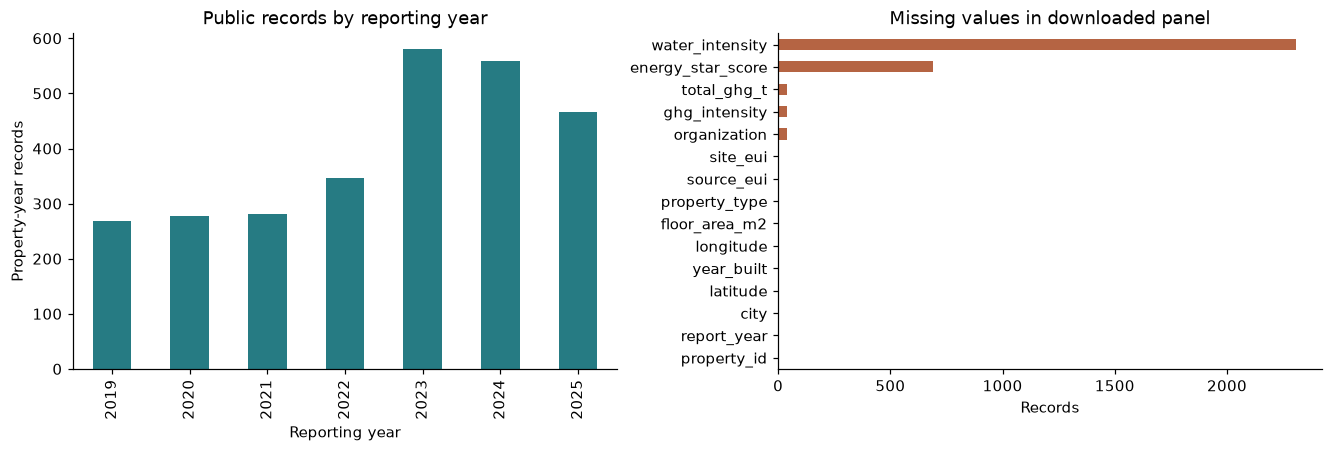

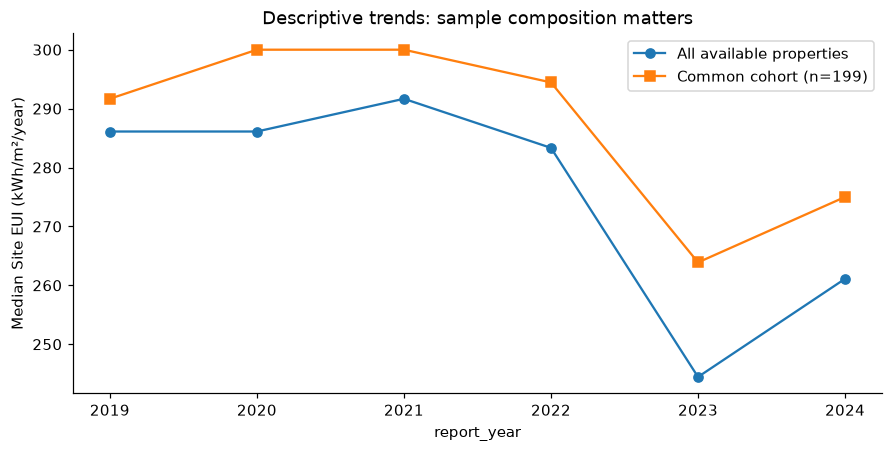

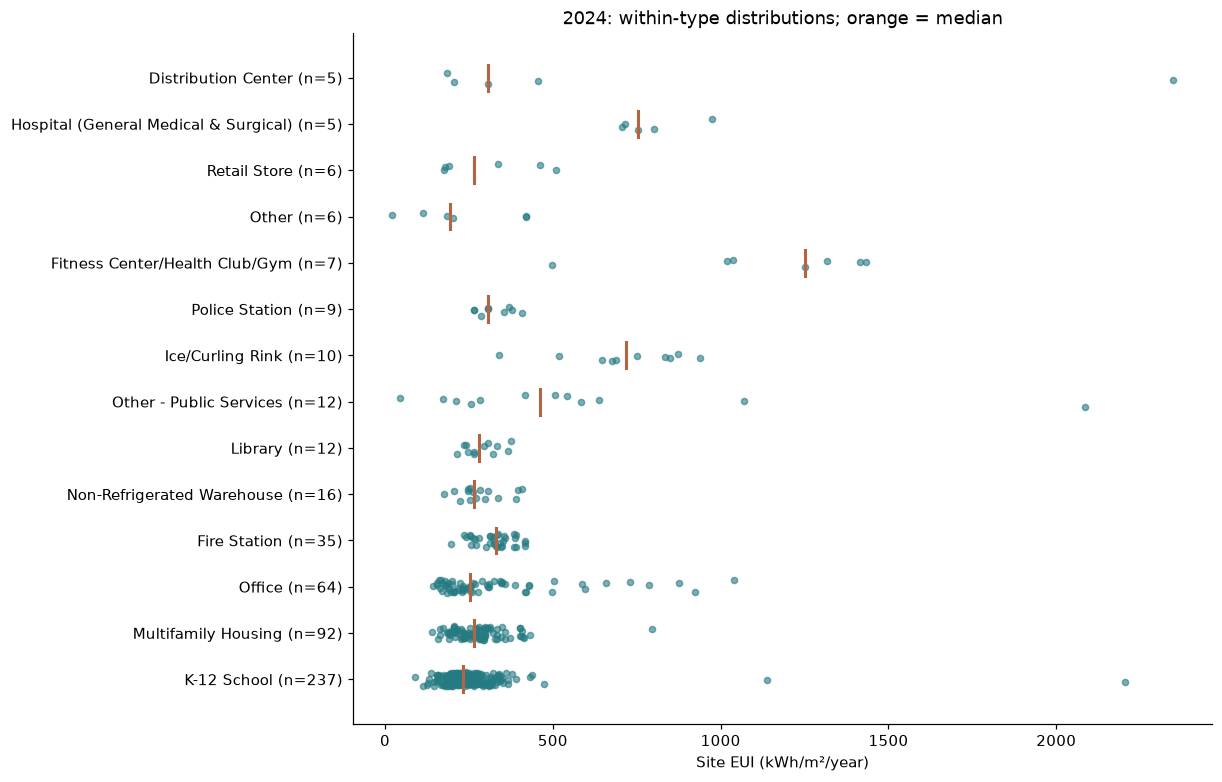

In [3]:
def save_plot(fig,name):
    fig.savefig(OUT/f'{name}.png',dpi=200,bbox_inches='tight')
    fig.savefig(OUT/f'{name}.svg',bbox_inches='tight')
    display(fig);plt.close(fig)

fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
d.groupby('report_year').size().plot.bar(ax=axes[0],color='#267b83')
axes[0].set(title='Public records by reporting year',ylabel='Property-year records',xlabel='Reporting year')
raw.isna().sum().sort_values().plot.barh(ax=axes[1],color='#b56443')
axes[1].set(title='Missing values in downloaded panel',xlabel='Records')
save_plot(fig,'01_coverage')

years=list(range(2019,2025))
cohort=d[d.report_year.isin(years)].groupby('property_id').report_year.nunique()
ids=cohort[cohort==len(years)].index
fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
d[d.report_year.isin(years)].groupby('report_year').site_eui.median().plot(ax=ax,marker='o',label='All available properties')
d[d.property_id.isin(ids)&d.report_year.isin(years)].groupby('report_year').site_eui.median().plot(ax=ax,marker='s',label=f'Common cohort (n={len(ids)})')
ax.set(ylabel='Median Site EUI (kWh/m²/year)',title='Descriptive trends: sample composition matters')
ax.legend();save_plot(fig,'02_cohort_trend')

snapshot=d[d.report_year==2024]
types=snapshot.property_type.value_counts();types=types[types>=5].index
fig,ax=plt.subplots(figsize=(11,7),layout='constrained')
rng=np.random.default_rng(SEED)
for i,t in enumerate(types):
    v=snapshot.loc[snapshot.property_type==t,'site_eui']
    ax.scatter(v,np.full(len(v),i)+rng.uniform(-.15,.15,len(v)),s=16,alpha=.6,color='#267b83')
    ax.plot([v.median()]*2,[i-.28,i+.28],color='#b56443',lw=2)
ax.set_yticks(range(len(types)),[f'{t} (n={sum(snapshot.property_type==t)})' for t in types])
ax.set(xlabel='Site EUI (kWh/m²/year)',title='2024: within-type distributions; orange = median')
save_plot(fig,'03_property_types_2024')


## ۴. تعریف مدل‌های ثابت و مبناها
ورودی‌ها کاربری، لگاریتم مساحت، سال ساخت و سال گزارش‌اند. اندازه‌گیری‌های هم‌زمان انرژی، انتشار، آب و ENERGY STAR وارد مدل نمی‌شوند. شناسه، سازمان و مختصات برای ارزیابی یا ممیزی‌اند.

پارامتر Ridge برابر alpha=10 است. Random Forest دارای ۲۰۰ درخت، عمق حداکثر ۶ و حداقل ۵ مشاهده در برگ است. پارامترها ثابت‌اند. مبناها میانهٔ کل آموزش و میانهٔ کاربری در آموزش‌اند؛ کاربری ندیده از میانهٔ کل استفاده می‌کند. املاک دارای سال‌های بیشتر وزن بیشتری در آموزش دارند؛ وزن‌دهی مساوی املاک نیازمند تحلیل حساسیت است.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
num=['log_floor_area','year_built','report_year']
features=['property_type']+num
X=d[features].copy();y=d.site_eui.to_numpy()
def model(name):
    prep=ColumnTransformer([
      ('numeric',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num),
      ('category',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),['property_type'])])
    est=Ridge(alpha=10) if name=='Ridge' else RandomForestRegressor(n_estimators=200,max_depth=6,min_samples_leaf=5,random_state=SEED,n_jobs=1)
    return Pipeline([('prep',prep),('model',est)])
def metrics(g):
    return {'n':len(g),'MAE':mean_absolute_error(g.observed,g.predicted),
      'RMSE':np.sqrt(mean_squared_error(g.observed,g.predicted)),
      'R2':r2_score(g.observed,g.predicted) if len(g)>1 else np.nan}
def evaluate(splits,scheme):
    records=[]
    for fold,(train,test) in enumerate(splits):
        lookup=pd.DataFrame({'type':d.iloc[train].property_type,'value':y[train]}).groupby('type').value.median()
        pred={'Global median':np.full(len(test),np.median(y[train])),
              'Type median':d.iloc[test].property_type.map(lookup).fillna(np.median(y[train])).to_numpy()}
        for name in ['Ridge','Random forest']:
            pred[name]=model(name).fit(X.iloc[train],y[train]).predict(X.iloc[test])
        seen=set(d.iloc[train].property_id)
        for name,values in pred.items():
            for pos,p in zip(test,values):
                records.append({'scheme':scheme,'fold':fold,'model':name,
                 'property_id':d.iloc[pos].property_id,'report_year':int(d.iloc[pos].report_year),
                 'seen_property':d.iloc[pos].property_id in seen,
                 'observed':float(y[pos]),'predicted':float(p)})
    return pd.DataFrame(records)


## ۵. ارزیابی ملک جدید و انتقال مکانی
اعتبارسنجی پنج‌بخشی فقط روی سال‌های ۲۰۱۹ تا ۲۰۲۳ انجام می‌شود. همهٔ سال‌های یک ملک در یک بخش باقی می‌مانند. گروه‌های مکانی با شبکهٔ تقریبی ۵ کیلومتری، مبدأ ثابت و میانهٔ مختصات هر ملک ساخته می‌شوند.

بلوک‌های آموزش و آزمون مشترک نیستند، اما حاشیهٔ حذف در مرز بلوک‌ها اعمال نشده است؛ املاک نزدیک مرز می‌توانند در دو سمت قرار بگیرند. این آزمون درون‌شهری است و انتقال به اقلیم یا شهر دیگر را اثبات نمی‌کند.

,scheme,model,n,MAE,RMSE,R2
0,New property / 2019-2023,Global median,1754,134.535195,263.802332,-0.093648
1,New property / 2019-2023,Random forest,1754,107.018366,188.598139,0.441021
2,New property / 2019-2023,Ridge,1754,104.665958,181.430618,0.482701
3,New property / 2019-2023,Type median,1754,102.890908,185.058599,0.461806
4,Spatial blocks 5km / 2019-2023,Global median,1754,134.541525,263.630162,-0.092221
5,Spatial blocks 5km / 2019-2023,Random forest,1754,109.186863,188.832312,0.439633
6,Spatial blocks 5km / 2019-2023,Ridge,1754,104.252474,179.914459,0.491311
7,Spatial blocks 5km / 2019-2023,Type median,1754,105.539632,187.937931,0.444928


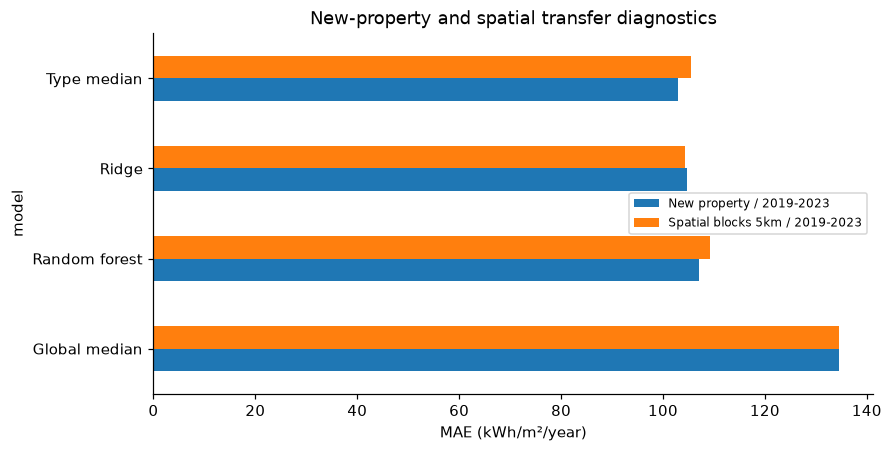

In [5]:
from benchmarkyyc.splits import property_splits, spatial_splits
property_folds=list(property_splits(d,through_year=2023,n_splits=5))
spatial_folds=list(spatial_splits(d,through_year=2023,n_splits=5,block_km=5))
for train,test in property_folds+spatial_folds:
    assert set(d.iloc[train].property_id).isdisjoint(d.iloc[test].property_id)
    assert d.iloc[train].report_year.max()<=2023
property_cv=evaluate(property_folds,'New property / 2019-2023')
spatial_cv=evaluate(spatial_folds,'Spatial blocks 5km / 2019-2023')
cv=pd.concat([property_cv,spatial_cv],ignore_index=True)
summary=pd.DataFrame([{'scheme':s,'model':m,**metrics(g)} for (s,m),g in cv.groupby(['scheme','model'])])
display(summary)
cv.to_csv(OUT/'group_spatial_predictions.csv',index=False)
summary.to_csv(OUT/'group_spatial_metrics.csv',index=False)
fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
summary.pivot(index='model',columns='scheme',values='MAE').plot.barh(ax=ax)
ax.set(xlabel='MAE (kWh/m²/year)',title='New-property and spatial transfer diagnostics')
ax.legend(fontsize=8);save_plot(fig,'04_group_spatial_validation')


## ۶. ارزیابی سال‌های بعد
برای هر سال آزمون، فقط سال‌های قبل آموزش هستند. املاک دیده‌شده و جدید جداگانه گزارش می‌شوند. آزمون ۲۰۲۴ مقایسهٔ اصلی است؛ ۲۰۲۲ و ۲۰۲۳ برای بررسی تاریخی و ۲۰۲۵ به‌صورت موقت گزارش می‌شوند.

برای ملک دارای مشاهدهٔ سال قبل، مبنای تداوم مصرف همان مقدار را بدون تغییر پیش‌بینی می‌کند. همهٔ مدل‌ها روی همین زیرمجموعه مقایسه می‌شوند. این کاربرد با تخمین مصرف ملک فاقد سابقه متفاوت است.

,scheme,model,n,MAE,RMSE,R2
0,Temporal 2022,Global median,346,131.310058,249.120941,-0.068484
1,Temporal 2022,Random forest,346,100.978176,150.362243,0.610753
2,Temporal 2022,Ridge,346,100.546282,161.372242,0.551662
3,Temporal 2022,Type median,346,87.704606,148.283396,0.621442
4,Temporal 2023,Global median,580,123.836045,241.830766,-0.011026
5,Temporal 2023,Random forest,580,97.724703,172.471542,0.485750
6,Temporal 2023,Ridge,580,93.337377,179.272259,0.444396
7,Temporal 2023,Type median,580,87.854332,174.981515,0.470674
8,Temporal 2024,Global median,559,115.796992,244.366843,-0.050627
9,Temporal 2024,Random forest,559,89.711808,182.250866,0.415609


,year,seen_property,model,n,MAE,RMSE,R2
16,2024,False,Global median,11,107.070585,125.428431,-0.238593
17,2024,False,Random forest,11,131.948793,149.573406,-0.761349
18,2024,False,Ridge,11,153.573679,183.201525,-1.642377
19,2024,False,Type median,11,167.676574,192.607452,-1.920672
20,2024,True,Global median,548,115.972157,246.166654,-0.049798
21,2024,True,Random forest,548,88.863985,182.847021,0.420808
22,2024,True,Ridge,548,85.795989,186.784446,0.395594
23,2024,True,Type median,548,84.124076,187.677299,0.389802


,year,model,n,MAE,RMSE,R2
8,2024,Global median,547,116.184172,246.391566,-0.049893
9,2024,Random forest,547,88.957827,183.007045,0.420799
10,2024,Ridge,547,85.908808,186.952267,0.395558
11,2024,Type median,547,84.232164,187.845730,0.389766
18,2024,Previous year EUI,547,32.398933,59.857069,0.938038


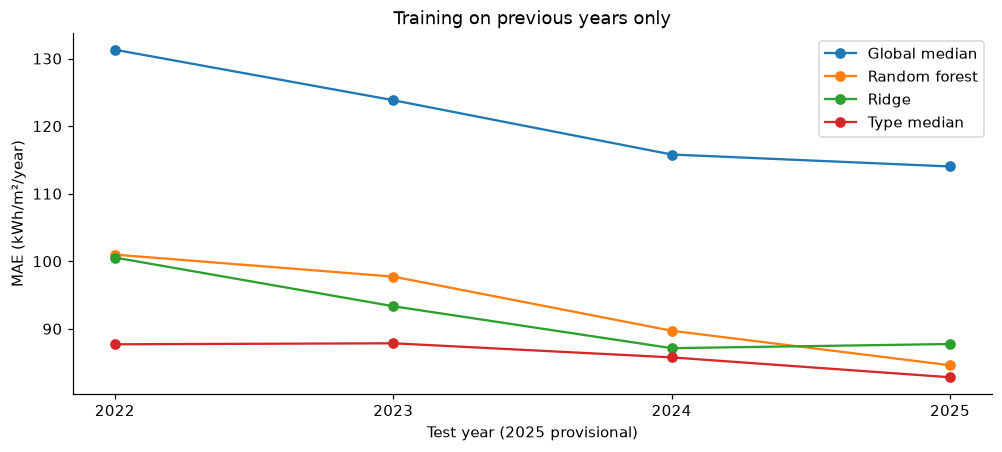

In [6]:
from benchmarkyyc.splits import temporal_split
time_results=[]
for year in [2022,2023,2024,2025]:
    train,test=temporal_split(d,year)
    p=evaluate([(train,test)],f'Temporal {year}'+(' (provisional)' if year==2025 else ''))
    time_results.append(p)
temporal=pd.concat(time_results,ignore_index=True)
time_metrics=pd.DataFrame([{'scheme':s,'model':m,**metrics(g)} for (s,m),g in temporal.groupby(['scheme','model'])])
display(time_metrics)
subgroup=pd.DataFrame([{'year':yr,'seen_property':seen,'model':m,**metrics(g)} for (yr,seen,m),g in temporal.groupby(['report_year','seen_property','model'])])
display(subgroup[subgroup.year==2024])
lag=d[['property_id','report_year','site_eui']].copy();lag.report_year+=1
lag=lag.rename(columns={'site_eui':'previous_year_eui'})
lag_results=temporal.merge(lag,on=['property_id','report_year'],how='left').dropna(subset=['previous_year_eui'])
lag_metrics=[]
for (year,name),g in lag_results.groupby(['report_year','model']):
    lag_metrics.append({'year':year,'model':name,**metrics(g)})
for year,g in lag_results[lag_results.model=='Random forest'].groupby('report_year'):
    g=g.copy();g['predicted']=g.previous_year_eui
    lag_metrics.append({'year':year,'model':'Previous year EUI',**metrics(g)})
lag_metrics=pd.DataFrame(lag_metrics)
display(lag_metrics[lag_metrics.year==2024])
temporal.to_csv(OUT/'temporal_predictions.csv',index=False)
time_metrics.to_csv(OUT/'temporal_metrics.csv',index=False)
subgroup.to_csv(OUT/'temporal_seen_unseen_metrics.csv',index=False)
lag_metrics.to_csv(OUT/'previous_year_baseline_comparison.csv',index=False)
fig,ax=plt.subplots(figsize=(9,4),layout='constrained')
for name,g in time_metrics.groupby('model'):
    ax.plot([int(s.split()[1]) for s in g.scheme],g.MAE,marker='o',label=name)
ax.set_xticks([2022,2023,2024,2025])
ax.set(xlabel='Test year (2025 provisional)',ylabel='MAE (kWh/m²/year)',title='Training on previous years only');ax.legend()
save_plot(fig,'05_temporal_validation')


## ۷. خطا و عدم‌قطعیت شرطی
مقایسهٔ جفت‌شده، MAE مدل Random Forest منهای MAE میانهٔ کاربری در ۲۰۲۴ است. در ۲۰۰۰ تکرار بوت‌استرپ، املاک آزمون بازنمونه‌گیری و مدل‌ها ثابت نگه داشته می‌شوند. بازهٔ حاصل عدم‌قطعیت بازآموزی، اصلاح منبع یا مشارکت انتخابی را پوشش نمی‌دهد.

باقیماندهٔ مثبت یعنی مصرف از پیش‌بینی بیشتر بوده است؛ این مقدار برآورد انرژی قابل اجتناب یا صرفه‌جویی بهسازی نیست.

comparison                        RF MAE minus type-median MAE; 2024
difference                                                  3.943586
conditional_bootstrap_95_lower                             -2.296388
conditional_bootstrap_95_upper                             10.177335
n_properties                                                     559
dtype: object

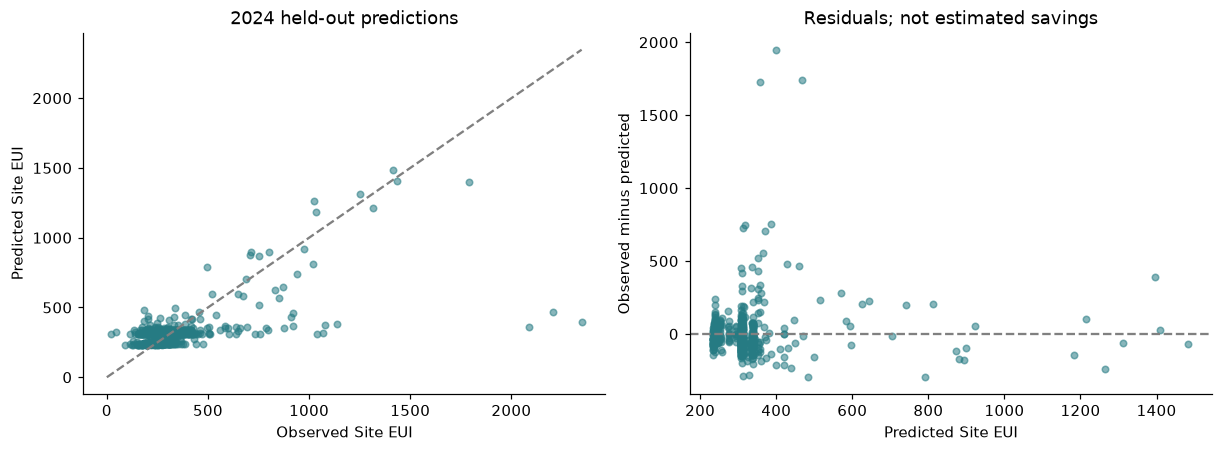

In [7]:
p24=temporal[temporal.report_year==2024]
wide=p24.pivot(index='property_id',columns='model',values='predicted')
truth=p24.groupby('property_id')['observed'].first().reindex(wide.index)
delta=np.abs(wide['Random forest']-truth)-np.abs(wide['Type median']-truth)
rng=np.random.default_rng(SEED)
boot=np.array([rng.choice(delta.to_numpy(),size=len(delta),replace=True).mean() for _ in range(2000)])
interval={'comparison':'RF MAE minus type-median MAE; 2024','difference':float(delta.mean()),
          'conditional_bootstrap_95_lower':float(np.quantile(boot,.025)),
          'conditional_bootstrap_95_upper':float(np.quantile(boot,.975)),'n_properties':len(delta)}
display(pd.Series(interval));(OUT/'paired_mae_uncertainty.json').write_text(json.dumps(interval,indent=2),encoding='utf-8')
g=p24[p24.model=='Random forest'].copy()
fig,axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
axes[0].scatter(g.observed,g.predicted,s=18,alpha=.55,color='#267b83')
end=max(g.observed.max(),g.predicted.max());axes[0].plot([0,end],[0,end],'--',color='gray')
axes[0].set(xlabel='Observed Site EUI',ylabel='Predicted Site EUI',title='2024 held-out predictions')
axes[1].scatter(g.predicted,g.observed-g.predicted,s=18,alpha=.55,color='#267b83')
axes[1].axhline(0,color='gray',ls='--');axes[1].set(xlabel='Predicted Site EUI',ylabel='Observed minus predicted',title='Residuals; not estimated savings')
save_plot(fig,'06_2024_residuals')


## ۸. تفسیر پیش‌بینی‌های خارج از آموزش
Exact SHAP ترکیب‌های چهار ویژگی اصلی را با خود تابع پیش‌بینی Random Forest محاسبه می‌کند. کاربری یک ویژگی واحد است. ۱۰۰ ملک آزمون ۲۰۲۴ و ۵۰ مشاهدهٔ پس‌زمینهٔ آموزش با بذر تصادفی ثابت انتخاب می‌شوند.

جمع‌پذیری با تابع پیش‌بینی کنترل می‌شود. اهمیت‌ها به همین مدل و نمونهٔ مرجع وابسته‌اند و اثر علّی تصمیم طراحی یا بهسازی را نشان نمی‌دهند. پایداری نسبت به تقسیم‌های متفاوت آموزش هنوز بررسی نشده است.

report_year        0.177385
year_built         3.978619
log_floor_area    26.754973
property_type     49.671429
Name: mean_absolute_SHAP, dtype: float64

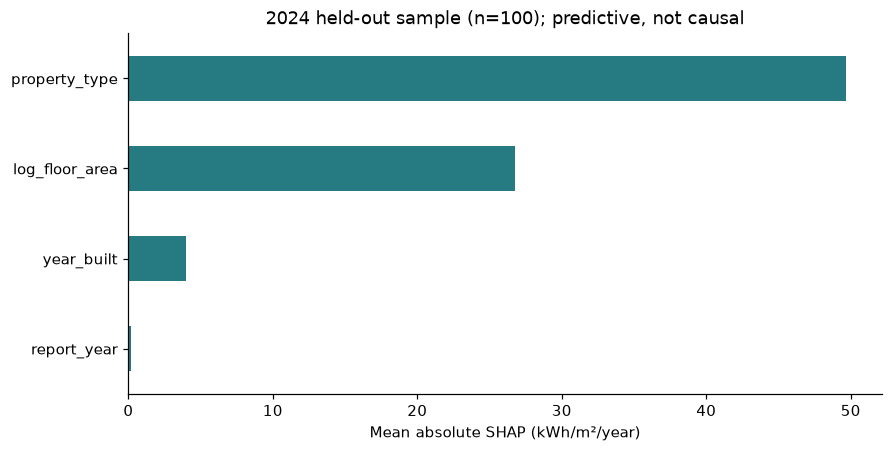

Exact SHAP additive consistency checked. Maximum error: 7.958078640513122e-13


In [8]:
import shap
train=np.flatnonzero(d.report_year.to_numpy()<=2023)
test=np.flatnonzero(d.report_year.to_numpy()==2024)
rf=model('Random forest').fit(X.iloc[train],y[train])
prep=rf.named_steps['prep']
z_train=prep.transform(X.iloc[train]);z_test=prep.transform(X.iloc[test])
def compact(z):
    category=np.where(z[:,3:].sum(axis=1)>0,np.argmax(z[:,3:],axis=1),-1)
    return np.column_stack([z[:,:3],category])
def predict_compact(q):
    expanded=np.zeros((len(q),z_train.shape[1]))
    expanded[:,:3]=q[:,:3]
    category=q[:,3].astype(int)
    known=(category>=0)&(category<z_train.shape[1]-3)
    expanded[np.flatnonzero(known),category[known]+3]=1
    return rf.named_steps['model'].predict(expanded)
rng=np.random.default_rng(SEED)
background=compact(z_train[rng.choice(len(z_train),50,replace=False)])
chosen=np.sort(rng.choice(len(z_test),min(100,len(z_test)),replace=False))
q_test=compact(z_test[chosen])
assert np.allclose(predict_compact(q_test),rf.predict(X.iloc[test[chosen]]))
explainer=shap.Explainer(predict_compact,shap.maskers.Independent(background,max_samples=50),algorithm='exact')
explanation=explainer(q_test,max_evals=16)
values=explanation.values
names=num+['property_type']
shap_summary=pd.Series(np.abs(values).mean(axis=0),index=names,name='mean_absolute_SHAP').sort_values()
display(shap_summary)
shap_summary.to_csv(OUT/'shap_2024_summary.csv')
pd.DataFrame({'property_id':d.iloc[test[chosen]].property_id.to_numpy(),**{name:values[:,i] for i,name in enumerate(names)}}).to_csv(OUT/'shap_2024_sample_values.csv',index=False)
fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
shap_summary.plot.barh(ax=ax,color='#267b83')
ax.set(xlabel='Mean absolute SHAP (kWh/m²/year)',title='2024 held-out sample (n=100); predictive, not causal')
save_plot(fig,'07_shap_2024')
max_error=np.max(np.abs(values.sum(axis=1)+explanation.base_values-predict_compact(q_test)))
assert max_error<1e-6
print('Exact SHAP additive consistency checked. Maximum error:',max_error)
